In [1]:
!pip install tensorflow matplotlib pandas

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)

Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.2917 - loss: 1.8906 - val_accuracy: 0.4300 - val_loss: 1.5670
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4376 - loss: 1.5459 - val_accuracy: 0.4940 - val_loss: 1.3999
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4986 - loss: 1.3939 - val_accuracy: 0.5190 - val_loss: 1.3686
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5463 - loss: 1.2587 - val_accuracy: 0.5550 - val_loss: 1.2220
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6013 - loss: 1.1233 - val_accuracy: 0.5855 - val_loss: 1.1952

Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━

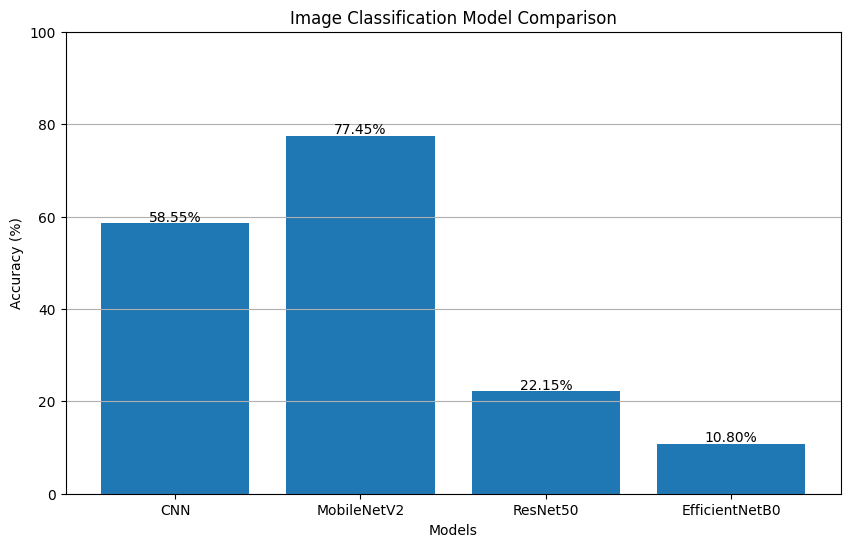


Best Model: MobileNetV2
Best Accuracy: 77.45 %


In [1]:


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =====================================================
# LOAD CIFAR-10 DATASET
# =====================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use subset to reduce memory usage
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =====================================================
# CREATE DATASET PIPELINE
# =====================================================

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}

# =====================================================
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

# =====================================================
# FUNCTION FOR TRANSFER LEARNING MODELS
# =====================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================
# MOBILE NET V2
# =====================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

# =====================================================
# RESNET50
# =====================================================

train_pretrained(
    ResNet50,
    "ResNet50"
)

# =====================================================
# EFFICIENTNET B0
# =====================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

# =====================================================
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

# =====================================================
# BAR GRAPH
# =====================================================

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")

